In [31]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.transforms as T
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
from PIL import Image

In [32]:
ice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [33]:
def train(model, device, train_loader, optimizer, loss_fn, epoch):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = loss_fn(output, target)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * data.size(0)
        total_samples += data.size(0)


        if batch_idx % 200 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} "
                  f"({100. * batch_idx / len(train_loader):.0f}%)]\tBatch Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total_samples
    return epoch_loss

In [36]:
def test(model, device, test_loader, loss_fn):

    model.eval()
    test_loss = 0
    correct = 0


    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            test_loss += loss_fn(output, target).item() * data.size(0)


            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"\n--> Test Set: Average Loss: {test_loss:.4f}, "
          f"Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")
    return test_loss, accuracy


if __name__ == "__main__":
    model = MNISTNet().to(device)


    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adadelta(model.parameters(), lr=1.0)
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

    epoch_list = []
    train_losses = []
    test_losses = []
    test_accuracies = []

    num_epochs = 5
    print(f"Starting Training on Device: {device}\n" + "="*40)

    for epoch in range(1, num_epochs + 1):
        tr_loss = train(model, device, train_loader, optimizer, loss_function, epoch)
        te_loss, te_acc = test(model, device, test_loader, loss_function)

        scheduler.step()


        epoch_list.append(epoch)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        test_accuracies.append(te_acc)

Starting Training on Device: cpu
Train Epoch: 1 [0/60000 (0%)]	Batch Loss: 2.2929


KeyboardInterrupt: 

Model state parameters successfully persisted to 'mnist_cnn_state.pt'


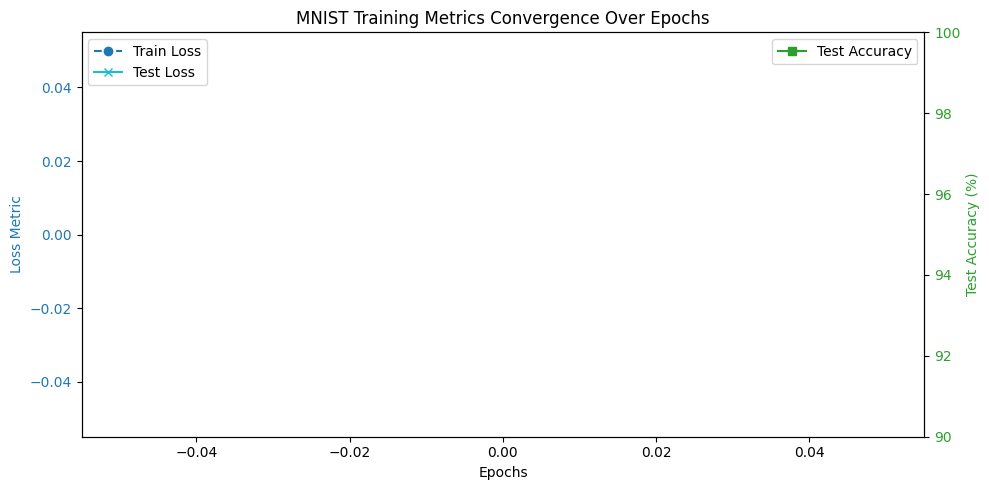


Executing Independent Disk-Load and Inference Test Case...
Inference Execution Result -> Decoded Digit Class: 7


In [37]:
    MODEL_PATH = 'mnist_cnn_state.pt'
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model state parameters successfully persisted to '{MODEL_PATH}'")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss Metric', color=color)
    ax1.plot(epoch_list, train_losses, label='Train Loss', color=color, linestyle='--', marker='o')
    ax1.plot(epoch_list, test_losses, label='Test Loss', color='tab:cyan', linestyle='-', marker='x')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Test Accuracy (%)', color=color)
    ax2.plot(epoch_list, test_accuracies, label='Test Accuracy', color=color, linestyle='-', marker='s')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim([90, 100])
    ax2.legend(loc='upper right')

    plt.title('MNIST Training Metrics Convergence Over Epochs')
    fig.tight_layout()
    plt.savefig('mnist_training_performance.png', dpi=150)
    plt.show()

    print("\n" + "="*40 + "\nExecuting Independent Disk-Load and Inference Test Case...")

    IMAGE_FILENAME = 'my_digit.png'
    if not os.path.exists(IMAGE_FILENAME):
        dummy_img = Image.new('L', (28, 28), 0)
        dummy_img.save(IMAGE_FILENAME)
        print(f"Asset '{IMAGE_FILENAME}' generated safely on local path storage.")

    eval_model = MNISTNet().to(device)
    eval_model.load_state_dict(torch.load(MODEL_PATH, map_location=device if 'device' in locals() else None))
    eval_model.eval()


    inference_transform = T.Compose([
        T.Grayscale(),
        T.Resize((28, 28)),
        T.ToTensor(),
        T.Normalize((0.1307,), (0.3081,))
    ])

    raw_image = Image.open(IMAGE_FILENAME)

    processed_tensor = inference_transform(raw_image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction_logits = eval_model(processed_tensor)
        predicted_digit = prediction_logits.argmax(dim=1).item()
        print(f"Inference Execution Result -> Decoded Digit Class: {predicted_digit}")